# **Одномерная линейная регрессия**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)

In [ ]:
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 3 * X + 5 + np.random.randn(50, 1) * 2

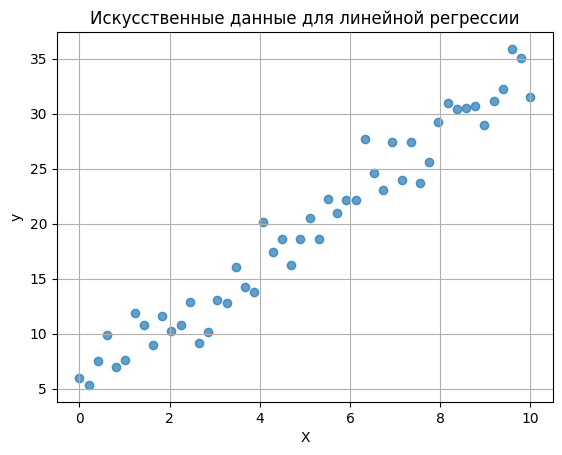

In [ ]:
plt.scatter(X, y, alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Искусственные данные для линейной регрессии")
plt.grid(True)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("w0 (intercept):", model.intercept_)
print("w1 (coefficient):", model.coef_)

w0 (intercept): [5.46439457]
w1 (coefficient): [[2.83457252]]


In [ ]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

MSE:  3.2196
RMSE: 1.7943
MAE:  1.4446
R^2:  0.9459


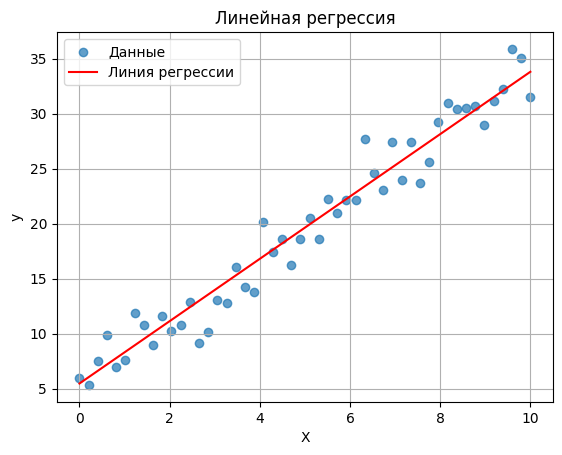

In [ ]:
plt.scatter(X, y, alpha=0.7, label="Данные")
X_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color="red", label="Линия регрессии")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)
plt.show()

Построить модель прогнозирования цены объекта недвижимости на основе площади (Одномерная линейная регрессия)

In [ ]:

X = [[40], [50], [100], [20], [45], [60], [55], [70], [47], [57], [80]] # Площадь объекта недвижимости
y = [10, 15, 30, 6, 11, 17, 16, 18, 14.5, 15.5, 25] # Цена

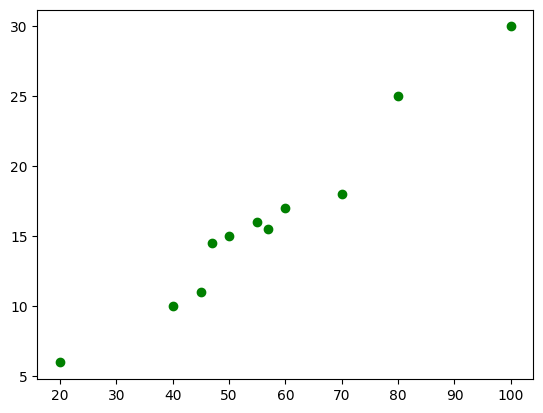

In [ ]:
# Визуализируем исходные данные
import matplotlib.pyplot as plt
plt.plot(X, y, 'go')
plt.show()

In [ ]:
# Делим на train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Используем библиотеку Sklearn для построения модели
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train) # обучение модели
# Выводим параметры модели
print("w0 (intercept):", model.intercept_)
print("w1 (coefficient):", model.coef_)
# Проверяем работу модели на тестовых данных
y_pred = model.predict(X_test) # предсказываем значения для тестовых данных

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

# Прогноз цен для новых объектов
print(model.predict([[150], [90]]))

w0 (intercept): -0.8159187684245026
w1 (coefficient): [0.30412709]
MSE:  1.0152
RMSE: 1.0076
MAE:  0.9334
R^2:  0.8879
[44.80314445 26.55551916]


Множественная линейная регрессия

In [ ]:
# Площадь объекта недвижимости, расстояние до метро (км).
X = [[40, 0.8], [40, 1.8], [50, 1], [100, 0.5], [20, 2], [45, 1.5], [60, 1.7], [55, 0.9], [70, 0.5], [47, 0.6], [57, 0.4], [80, 0.2]]
# Цена
y = [10, 9, 15, 30, 6, 11, 17, 16, 18, 14.5, 15.5, 25]

In [ ]:
import pandas as pd

data = {
    "area":      [40, 40, 50, 100, 20, 45, 60, 55, 70, 47, 57, 80],   # площадь, м²
    "distance":  [0.8, 1.8, 1.0, 0.5, 2.0, 1.5, 1.7, 0.9, 0.5, 0.6, 0.4, 0.2],  # расстояние до метро, км
}

X = pd.DataFrame(data)
#X = pd.read_csv("data.csv")
print(X)

    area  distance
0     40       0.8
1     40       1.8
2     50       1.0
3    100       0.5
4     20       2.0
5     45       1.5
6     60       1.7
7     55       0.9
8     70       0.5
9     47       0.6
10    57       0.4
11    80       0.2


In [ ]:
print(X['area'])

0      40
1      40
2      50
3     100
4      20
5      45
6      60
7      55
8      70
9      47
10     57
11     80
Name: area, dtype: int64


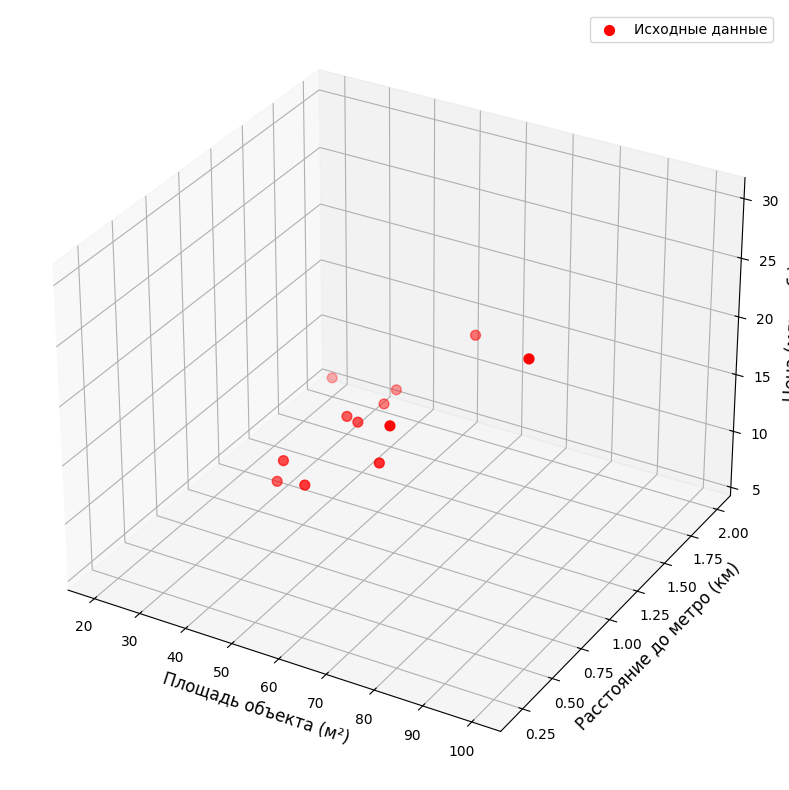

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Исходные данные
X = np.array(X)
y = np.array(y)

# Подготовка данных для построения поверхности
x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
x2_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Визуализация
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Добавление точек исходных данных
ax.scatter(X[:, 0], X[:, 1], y, color='red', s=50, label='Исходные данные')

# Настройка осей и подписей
ax.set_xlabel('Площадь объекта (м²)', fontsize=12)
ax.set_ylabel('Расстояние до метро (км)', fontsize=12)
ax.set_zlabel('Цена (млн руб.)', fontsize=12)

# Легенда и цветовая шкала
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Делим на train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Используем библиотеку Sklearn для построения модели
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train) # обучение модели
# Выводим параметры модели
print("w0 (intercept):", model.intercept_)
print("w1 (coefficient):", model.coef_)
# Проверяем работу модели на тестовых данных
y_pred = model.predict(X_test) # предсказываем значения для тестовых данных

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

# Прогноз цен для новых объектов
print(model.predict([[150, 0.5], [50, 1]]))

w0 (intercept): 0.14475509423132138
w1 (coefficient): [ 0.29651296 -0.84054817]
MSE:  1.3643
RMSE: 1.1680
MAE:  1.1554
R^2:  0.7616
[44.20142543 14.12985507]


In [ ]:
import numpy as np
import plotly.graph_objects as go

a = model.coef_[0]
b = model.coef_[1]
c = model.intercept_

# Подготовка данных для построения поверхности
x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
x2_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
X1, X2 = np.meshgrid(x1_range, x2_range)
Z = a * X1 + b * X2 + c

# Фигура Plotly
fig = go.Figure()

# Поверхность регрессии
fig.add_trace(go.Surface(
    x=X1,
    y=X2,
    z=Z,
    colorscale='Viridis',
    opacity=0.6,
    name='Поверхность регрессии',
    showscale=True
))

# Точки исходных данных
fig.add_trace(go.Scatter3d(
    x=X[:, 0],
    y=X[:, 1],
    z=y,
    mode='markers',
    marker=dict(size=6, color='red'),
    name='Исходные данные'
))

# Настройки сцены и заголовка
fig.update_layout(
    scene=dict(
        xaxis_title='Площадь объекта (м²)',
        yaxis_title='Расстояние до метро (км)',
        zaxis_title='Цена (млн руб.)'
    ),
    title='Модель линейной регрессии для прогнозирования цены недвижимости'
)

fig.show()


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrdaniilak/russia-real-estate-2021")

print("Path to dataset files:", path)

100%|██████████| 276M/276M [00:02<00:00, 109MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mrdaniilak/russia-real-estate-2021/versions/1


In [ ]:
import pandas as pd
df = pd.read_csv(path+"/input_data.csv", delimiter=';')

In [ ]:
df.head(10)

,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
0,2021-01-01,2451300,15,31,1,30.3,0.0,56.780112,60.699355,0,2,620000.0,NaN,66,1632918.0
1,2021-01-01,1450000,5,5,1,33.0,6.0,44.608154,40.138381,0,0,385000.0,NaN,1,NaN
2,2021-01-01,10700000,4,13,3,85.0,12.0,55.540060,37.725112,3,0,142701.0,242543.0,50,681306.0
3,2021-01-01,3100000,3,5,3,82.0,9.0,44.608154,40.138381,0,0,385000.0,NaN,1,NaN
4,2021-01-01,2500000,2,3,1,30.0,9.0,44.738685,37.713668,3,2,353960.0,439378.0,23,1730985.0
5,2021-01-01,1450000,5,5,2,47.0,6.0,48.511172,44.566846,2,0,400096.0,260588.0,34,1009994.0
6,2021-01-01,9000000,2,4,3,107.4,21.3,55.009914,82.934859,4,0,630102.0,233285.0,54,2823596.0
7,2021-01-01,2990000,1,2,3,54.0,7.0,51.834703,107.600571,0,0,670034.0,NaN,3,NaN
8,2021-01-01,2300000,16,18,1,39.7,11.5,45.003869,39.086511,4,0,350065.0,523822.0,23,1284243.0
9,2021-01-01,2290000,2,2,2,53.2,16.0,53.164362,45.033956,5,0,440003.0,NaN,58,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11358150 entries, 0 to 11358149
Data columns (total 15 columns):
 #   Column         Dtype  
---  ------         -----  
 0   date           object 
 1   price          int64  
 2   level          int64  
 3   levels         int64  
 4   rooms          int64  
 5   area           float64
 6   kitchen_area   float64
 7   geo_lat        float64
 8   geo_lon        float64
 9   building_type  int64  
 10  object_type    int64  
 11  postal_code    float64
 12  street_id      float64
 13  id_region      int64  
 14  house_id       float64
dtypes: float64(7), int64(7), object(1)
memory usage: 1.3+ GB


In [ ]:
df.describe()

,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
count,1.135815e+07,1.135815e+07,1.135815e+07,1.135815e+07,1.135815e+07,1.135815e+07,1.135815e+07,1.135815e+07,1.135815e+07,1.135815e+07,1.085038e+07,7.152596e+06,1.135815e+07,8.096207e+06
mean,6.787516e+06,6.426675e+00,1.176266e+01,1.719417e+00,5.310356e+01,-2.674071e+00,5.440394e+01,5.229570e+01,1.017820e+00,5.275366e-01,4.031717e+05,3.525623e+05,5.125515e+01,1.703792e+06
std,1.977118e+08,5.283144e+00,7.218441e+00,1.157606e+00,2.712845e+01,3.241855e+01,4.582962e+00,2.183899e+01,1.562077e+00,8.813503e-01,1.959618e+05,1.366485e+05,2.250527e+01,6.404578e+05
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,1.000000e+00,-1.000000e+02,4.143758e+01,-1.732189e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.161870e+05,1.000000e+00,5.886060e+05
25%,2.600000e+06,2.000000e+00,5.000000e+00,1.000000e+00,3.650000e+01,0.000000e+00,5.319411e+01,3.763847e+01,0.000000e+00,0.000000e+00,1.961580e+05,2.339150e+05,3.100000e+01,1.162465e+06
50%,3.995000e+06,5.000000e+00,1.000000e+01,2.000000e+00,4.670000e+01,6.500000e+00,5.564688e+01,4.202111e+01,0.000000e+00,0.000000e+00,4.000070e+05,3.502220e+05,5.400000e+01,1.703143e+06
75%,6.500000e+06,9.000000e+00,1.700000e+01,2.000000e+00,6.300000e+01,1.050000e+01,5.687362e+01,6.547322e+01,2.000000e+00,2.000000e+00,6.250070e+05,4.705370e+05,7.200000e+01,2.255297e+06
max,6.355524e+11,5.000000e+01,5.000000e+01,9.000000e+00,4.999000e+02,4.080000e+02,7.350889e+01,1.792583e+02,6.000000e+00,2.000000e+00,8.621630e+05,5.885970e+05,2.000000e+02,2.839173e+06


In [ ]:
X = df[['area']]
X

,area
0,30.3
1,33.0
2,85.0
3,82.0
4,30.0
...,...
11358145,65.0
11358146,56.9
11358147,37.0
11358148,36.0


In [ ]:
y = df['price']

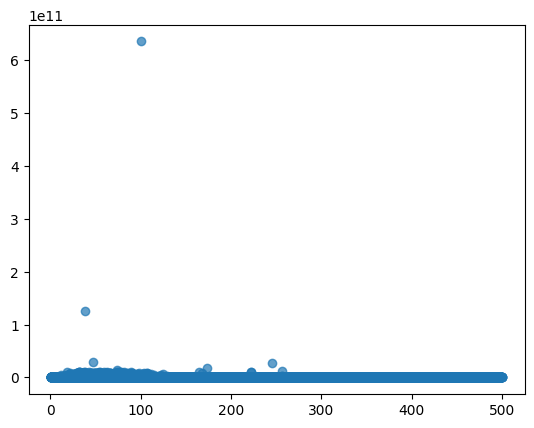

In [ ]:

plt.scatter(X, y, alpha=0.7, label="Данные")

In [ ]:
df = df[df['price']<10000000]

In [ ]:
df.describe()

,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
count,9.952851e+06,9.952851e+06,9.952851e+06,9.952851e+06,9.952851e+06,9.952851e+06,9.952851e+06,9.952851e+06,9.952851e+06,9.952851e+06,9.546163e+06,6.070144e+06,9.952851e+06,6.886103e+06
mean,4.030484e+06,6.102671e+00,1.117563e+01,1.618099e+00,4.895124e+01,-3.442725e+00,5.433226e+01,5.407343e+01,1.054211e+00,4.976644e-01,4.288375e+05,3.526474e+05,4.922536e+01,1.706241e+06
std,2.107615e+06,4.974483e+00,6.789271e+00,1.127300e+00,1.988053e+01,3.236767e+01,4.581810e+00,2.224937e+01,1.578771e+00,8.646728e-01,1.870090e+05,1.375762e+05,2.204423e+01,6.431392e+05
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,1.000000e+00,-1.000000e+02,4.143758e+01,-1.732189e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.161870e+05,1.000000e+00,5.886060e+05
25%,2.480000e+06,2.000000e+00,5.000000e+00,1.000000e+00,3.524000e+01,0.000000e+00,5.273395e+01,3.795685e+01,0.000000e+00,0.000000e+00,2.480330e+05,2.325020e+05,2.900000e+01,1.160439e+06
50%,3.600000e+06,5.000000e+00,9.000000e+00,2.000000e+00,4.469000e+01,6.000000e+00,5.545544e+01,4.597037e+01,0.000000e+00,0.000000e+00,4.238030e+05,3.517270e+05,5.200000e+01,1.694905e+06
75%,5.253643e+06,8.000000e+00,1.600000e+01,2.000000e+00,6.000000e+01,1.000000e+01,5.691647e+01,6.555392e+01,2.000000e+00,0.000000e+00,6.250290e+05,4.722350e+05,7.000000e+01,2.260832e+06
max,9.999999e+06,5.000000e+01,5.000000e+01,9.000000e+00,4.990000e+02,4.080000e+02,7.350889e+01,1.792583e+02,6.000000e+00,2.000000e+00,8.621630e+05,5.885970e+05,2.000000e+02,2.839173e+06


In [ ]:
X = pd.DataFrame(df['area'])

In [ ]:
y = df['price']

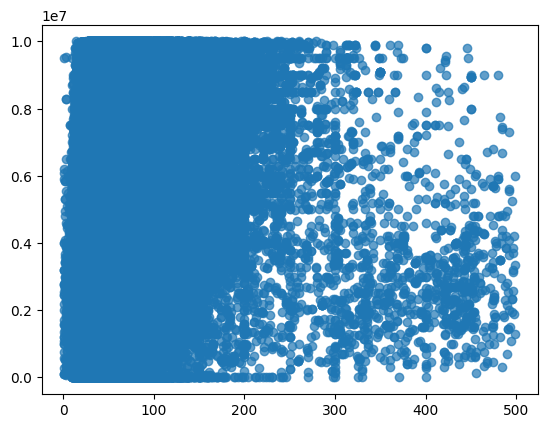

In [ ]:
plt.scatter(X, y, alpha=0.7, label="Данные")

In [ ]:
X = pd.DataFrame(df['area'])
X

,area
0,30.3
1,33.0
3,82.0
4,30.0
5,47.0
...,...
11358145,65.0
11358146,56.9
11358147,37.0
11358148,36.0


In [ ]:
y = df['price']
y

,price
0,2451300
1,1450000
3,3100000
4,2500000
5,1450000
...,...
11358145,6099000
11358146,2490000
11358147,850000
11358148,4360000


In [ ]:
# Делим на train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Используем библиотеку Sklearn для построения модели
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train) # обучение модели
# Выводим параметры модели
print("w0 (intercept):", model.intercept_)
print("w1 (coefficient):", model.coef_)
# Проверяем работу модели на тестовых данных
y_pred = model.predict(X_test) # предсказываем значения для тестовых данных

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

w0 (intercept): 1830306.5071873013
w1 (coefficient): [44948.28269601]
MSE:  3634006891034.7661
RMSE: 1906307.1345
MAE:  1484210.1544
R^2:  0.1798


In [ ]:
df['id_region'].unique()

array([ 66,   1,  23,  34,  54,   3,  58,  77,  72,  50,  78,  76,   2,
        40,  73,  18,  48,  27,  41,  63,  38,  15,  10,  39,  86,  16,
        47,   7,  26,   5,  91,  52,  56,  36,   9,  33,  31,  24,  57,
        74,  22,  17,  43,  32,  64,  59,  46,  44,  61,  42,  12,  71,
        29,  37,  21,  92,  51,  19,  70,  30,  75,  13,  69,  62,   8,
        35,  28,  68,  14,  20,  45,  55,  67,  25,  11,  89,  53,  60,
         6,  49,   4,  87,  65,  83, 200,  79])

In [ ]:
df48 = df.query('id_region == 48')

In [ ]:
df48.head(10)

,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
25,2021-01-01,1250000,2,2,3,70.70,11.0,52.859067,39.818296,4,0,399140.0,NaN,48,NaN
144,2021-01-01,2220000,11,18,1,37.01,0.0,52.587696,39.523726,0,0,398004.0,NaN,48,NaN
338,2021-01-01,2500000,3,11,1,44.00,0.0,52.599340,39.568217,0,0,398024.0,NaN,48,NaN
533,2021-01-01,730000,2,5,1,12.00,-100.0,52.537743,39.573170,4,0,398006.0,NaN,48,NaN
796,2021-01-01,2620000,7,14,2,52.00,9.0,59.958034,30.444417,4,0,195248.0,NaN,48,NaN
804,2021-01-01,1350000,3,5,1,30.90,6.1,52.612829,38.474387,4,0,399784.0,NaN,48,NaN
1280,2021-01-01,1580000,1,9,1,36.00,-100.0,52.587129,39.581805,2,0,398008.0,128672.0,48,1985774.0
1410,2021-01-01,2400000,5,5,3,58.00,-100.0,53.019170,39.127773,4,0,399610.0,NaN,48,NaN
1444,2021-01-01,780000,2,2,2,42.50,-100.0,52.606645,38.484927,4,0,399772.0,NaN,48,NaN
1454,2021-01-01,2150000,8,17,1,42.40,11.0,52.631889,39.546580,2,2,398037.0,189890.0,48,2052766.0


In [ ]:
df48.describe()

,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
count,4.385400e+04,43854.000000,43854.000000,43854.000000,43854.000000,43854.000000,43854.000000,43854.000000,43854.000000,43854.000000,42950.000000,3985.000000,43854.0,4.388000e+03
mean,2.820382e+06,5.823733,10.517057,1.885689,51.475795,-18.414345,52.646169,39.737315,0.593424,0.202901,398276.415809,323970.885571,48.0,1.843987e+06
std,1.404169e+06,4.704623,6.331306,0.950463,20.653324,46.318341,0.646444,3.703978,1.327436,0.603855,26697.653531,136472.527574,0.0,6.491716e+05
min,0.000000e+00,0.000000,0.000000,-1.000000,9.000000,-100.000000,43.094050,30.260316,0.000000,0.000000,101000.000000,119696.000000,48.0,5.890820e+05
25%,1.950000e+06,2.000000,5.000000,1.000000,38.000000,0.000000,52.585644,39.512879,0.000000,0.000000,398011.000000,201144.000000,48.0,1.457183e+06
50%,2.650000e+06,4.000000,9.000000,2.000000,47.300000,6.000000,52.596963,39.546652,0.000000,0.000000,398035.000000,319167.000000,48.0,1.985774e+06
75%,3.550000e+06,8.000000,17.000000,2.000000,62.400000,9.100000,52.613978,39.581334,0.000000,0.000000,398059.000000,460642.000000,48.0,2.354522e+06
max,9.999999e+06,25.000000,29.000000,9.000000,382.000000,78.000000,63.589238,158.672249,6.000000,2.000000,690035.000000,586281.000000,48.0,2.837861e+06


/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



<Axes: title={'center': 'Scatter Plot: X vs. н'}, xlabel='area', ylabel='price'>

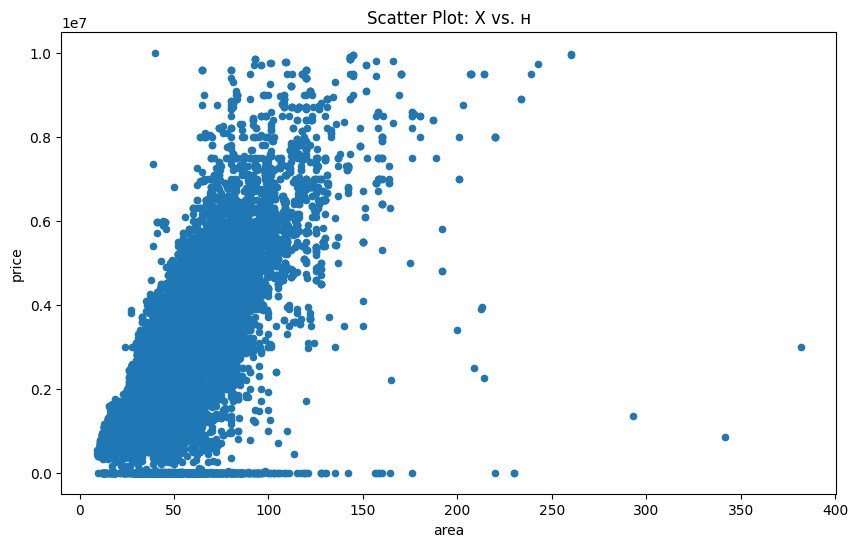

In [ ]:
# plt.scatter(X, y, alpha=0.7, label="Данные")
df48.plot.scatter(
    x="area", y="price",
    colormap="viridis",
    figsize=(10, 6),
    title='Scatter Plot: X vs. н'
)

<Axes: >

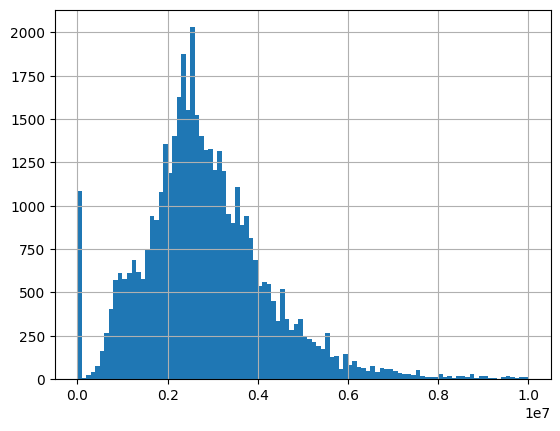

In [ ]:
df48['price'].hist(bins=100)

<Axes: >

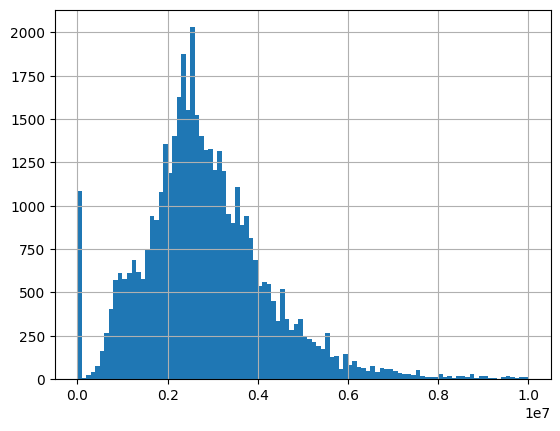

In [ ]:
df48['price'].hist(bins=100, range=(0,10000000))

In [ ]:
df48 = df48.query('price<5500000 and price>100000')

<Axes: >

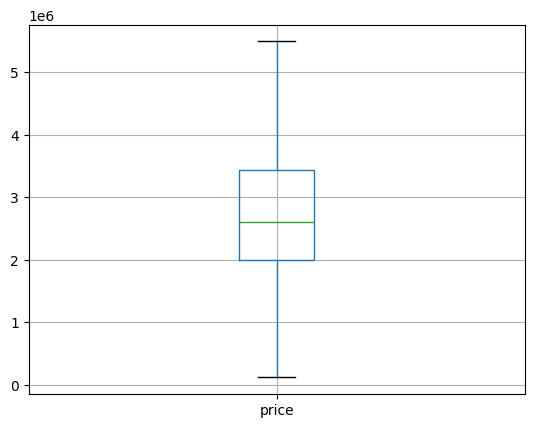

In [ ]:
df48.boxplot(column='price')

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



<Axes: title={'center': 'Scatter Plot: X vs. н'}, xlabel='area', ylabel='price'>

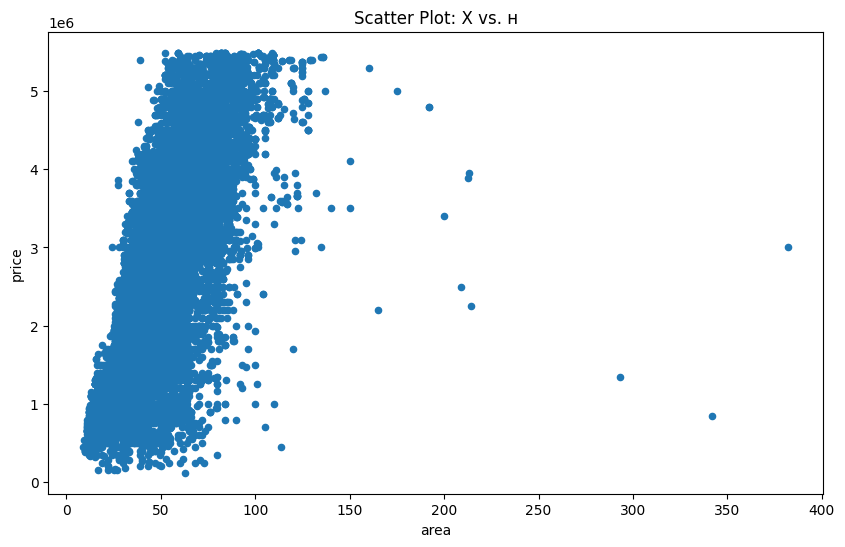

In [ ]:
df48.plot.scatter(
    x="area", y="price",
    colormap="viridis",
    figsize=(10, 6),
    title='Scatter Plot: X vs. н'
)

<Axes: >

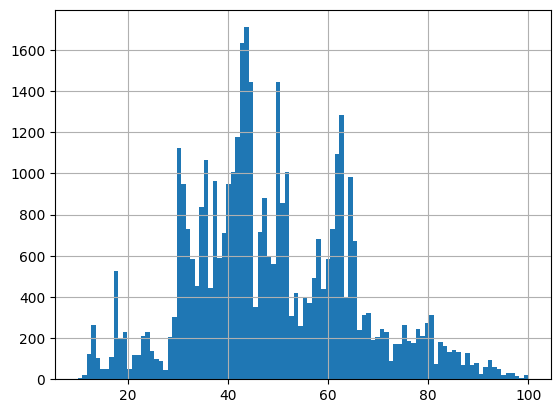

In [ ]:
df48['area'].hist(bins=100, range=(10,100))

In [ ]:
df48 = df48.query('area<90')

<Axes: >

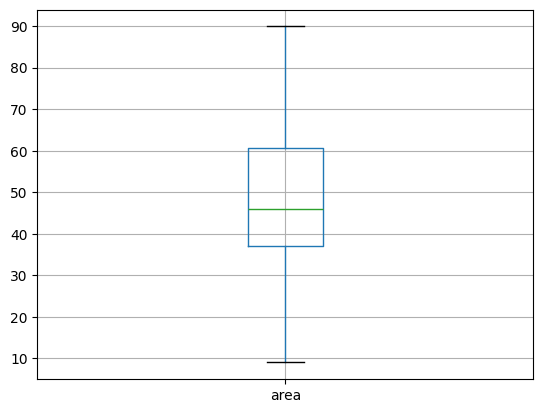

In [ ]:
df48.boxplot(column='area')

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



<Axes: title={'center': 'Scatter Plot: X vs. н'}, xlabel='area', ylabel='price'>

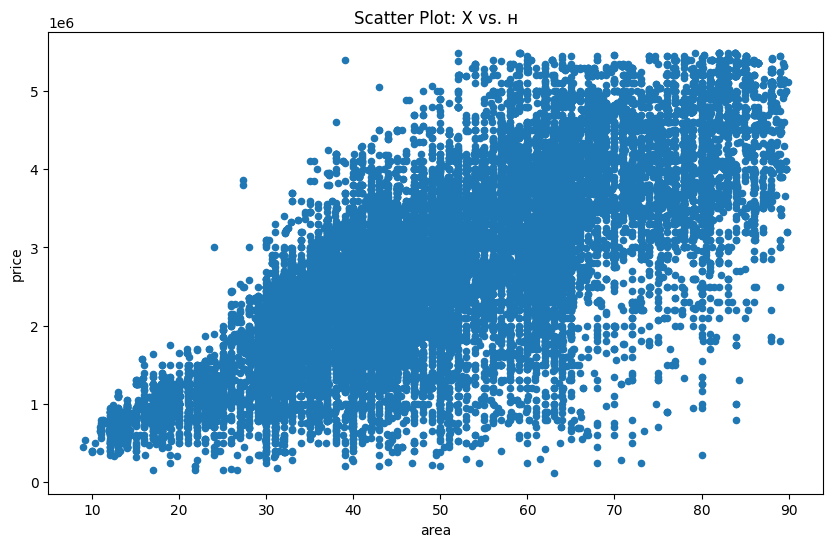

In [ ]:
df48.plot.scatter(
    x="area", y="price",
    colormap="viridis",
    figsize=(10, 6),
    title='Scatter Plot: X vs. н'
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = pd.DataFrame(df48['area'])
y = df48['price']

# Делим на train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Используем библиотеку Sklearn для построения модели
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train) # обучение модели
# Выводим параметры модели
print("w0 (intercept):", model.intercept_)
print("w1 (coefficient):", model.coef_)
# Проверяем работу модели на тестовых данных
y_pred = model.predict(X_test) # предсказываем значения для тестовых данных

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

w0 (intercept): 245982.0367183769
w1 (coefficient): [50359.99802478]
MSE:  461347880321.9639
RMSE: 679225.9420
MAE:  512999.8146
R^2:  0.5753


In [ ]:
df48['building_type'].unique()

array([4, 0, 2, 3, 5, 6])

In [ ]:
df['object_type'].unique()

array([2, 0])

In [ ]:
df['building_type'].unique()

array([0, 3, 2, 4, 5, 6, 1])

In [ ]:
df48 = df.query('id_region == 48')
#df48 = df48.query('object_type == 0')
df48 = df48.query('building_type==3')
df48 = df48.query('price>2000000 and price<6000000 and area < 90')

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



<Axes: title={'center': 'Scatter Plot: X vs. н'}, xlabel='area', ylabel='price'>

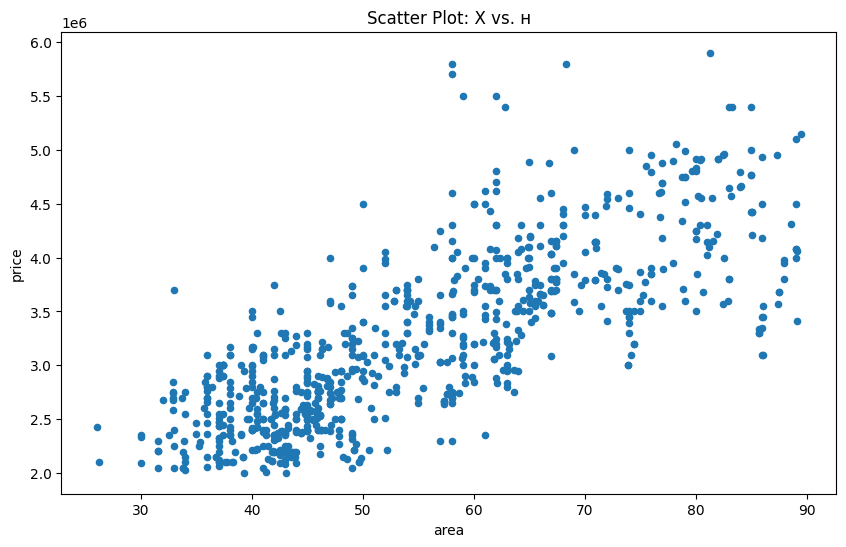

In [ ]:
df48.plot.scatter(
    x="area", y="price",
    colormap="viridis",
    figsize=(10, 6),
    title='Scatter Plot: X vs. н'
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = pd.DataFrame(df48['area'])
y = df48['price']

# Делим на train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Используем библиотеку Sklearn для построения модели
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train) # обучение модели
# Выводим параметры модели
print("w0 (intercept):", model.intercept_)
print("w1 (coefficient):", model.coef_)
# Проверяем работу модели на тестовых данных
y_pred = model.predict(X_test) # предсказываем значения для тестовых данных

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

w0 (intercept): 908511.6461850866
w1 (coefficient): [41783.35015628]
MSE:  273629203085.3180
RMSE: 523095.7877
MAE:  405882.7913
R^2:  0.5734


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



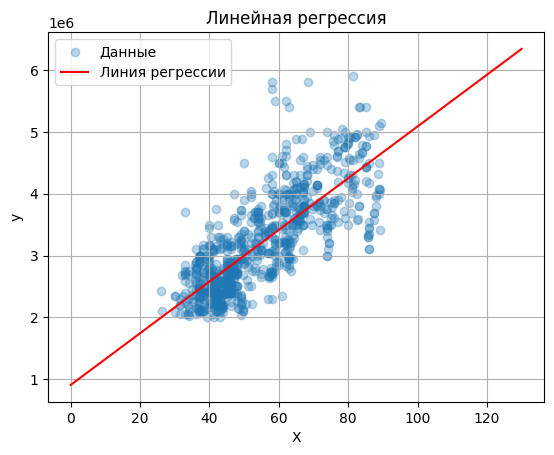

In [ ]:
plt.scatter(X, y, alpha=0.3, label="Данные")
X_line = np.linspace(0, 130, 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color="red", label="Линия регрессии")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)
plt.show()

#**Множественная линейная регрессия**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# X = df48[['area', 'rooms']]
X = df48[['area', 'rooms', 'level', 'kitchen_area']]

y = df48['price']

# Делим на train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Используем библиотеку Sklearn для построения модели
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train) # обучение модели
# Выводим параметры модели
print("w0 (intercept):", model.intercept_)
print("w1 (coefficient):", model.coef_)
# Проверяем работу модели на тестовых данных
y_pred = model.predict(X_test) # предсказываем значения для тестовых данных

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

w0 (intercept): 791179.4233605582
w1 (coefficient): [  48342.30666782 -147553.14602305    4542.47597565    1151.46440912]
MSE:  270774845474.8733
RMSE: 520360.3035
MAE:  401697.2532
R^2:  0.5779


In [ ]:
df48.info()

<class 'pandas.core.frame.DataFrame'>
Index: 829 entries, 3749 to 11269351
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           829 non-null    object 
 1   price          829 non-null    int64  
 2   level          829 non-null    int64  
 3   levels         829 non-null    int64  
 4   rooms          829 non-null    int64  
 5   area           829 non-null    float64
 6   kitchen_area   829 non-null    float64
 7   geo_lat        829 non-null    float64
 8   geo_lon        829 non-null    float64
 9   building_type  829 non-null    int64  
 10  object_type    829 non-null    int64  
 11  postal_code    802 non-null    float64
 12  street_id      255 non-null    float64
 13  id_region      829 non-null    int64  
 14  house_id       340 non-null    float64
dtypes: float64(7), int64(7), object(1)
memory usage: 103.6+ KB


<Axes: >

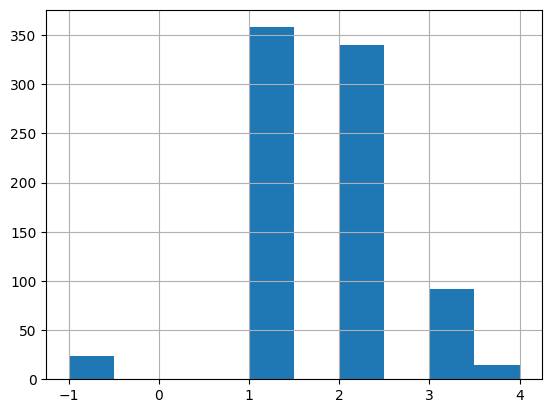

In [ ]:
df48['rooms'].hist(bins=10)

<Axes: >

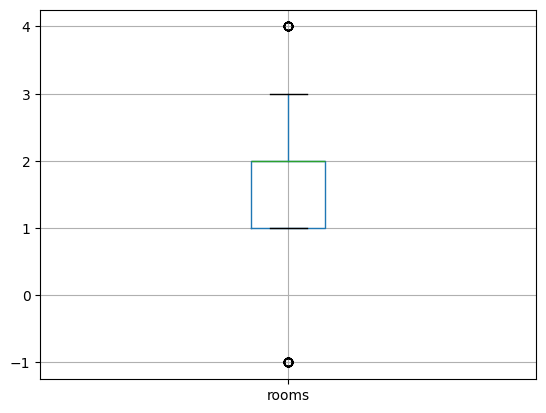

In [ ]:
df48.boxplot(column='rooms')

In [ ]:
df48 = df.query('id_region == 48')
#df48 = df48.query('object_type == 0')
df48 = df48.query('building_type==3')
df48 = df48.query('price>2000000 and price<6000000 and area < 90')
df48 = df48.query('rooms >=0 and rooms <4')

<Axes: >

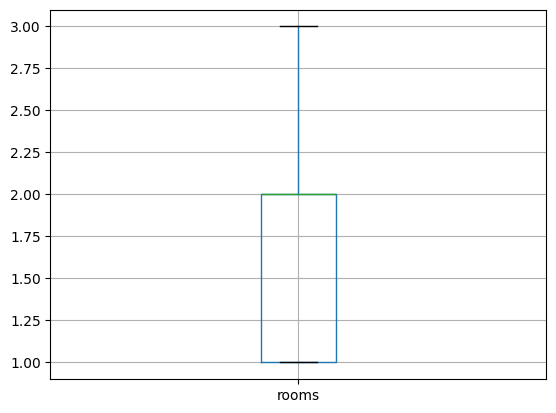

In [ ]:
df48.boxplot(column='rooms')

<Axes: >

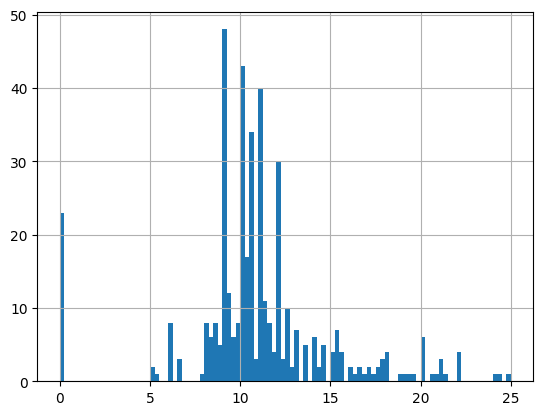

In [ ]:
df48['kitchen_area'].hist(bins=100, range=(0,25))

<Axes: >

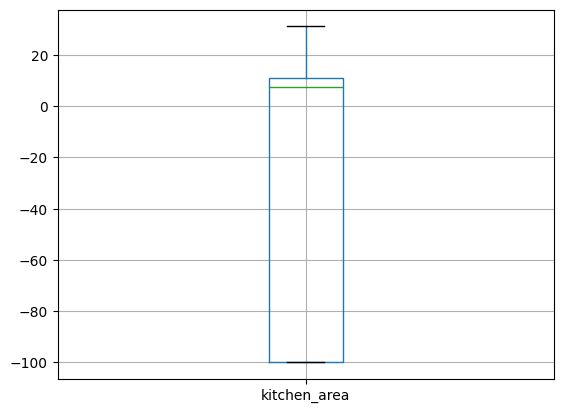

In [ ]:
df48.boxplot(column='kitchen_area')

In [ ]:
df48 = df.query('id_region == 48')
#df48 = df48.query('object_type == 0')
df48 = df48.query('building_type==3')
df48 = df48.query('price>2000000 and price<6000000 and area < 90')
df48 = df48.query('rooms >=0 and rooms <4')
df48 = df48.query('0<=kitchen_area<25')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9952851 entries, 0 to 11358149
Data columns (total 15 columns):
 #   Column         Dtype  
---  ------         -----  
 0   date           object 
 1   price          int64  
 2   level          int64  
 3   levels         int64  
 4   rooms          int64  
 5   area           float64
 6   kitchen_area   float64
 7   geo_lat        float64
 8   geo_lon        float64
 9   building_type  int64  
 10  object_type    int64  
 11  postal_code    float64
 12  street_id      float64
 13  id_region      int64  
 14  house_id       float64
dtypes: float64(7), int64(7), object(1)
memory usage: 1.2+ GB


/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



<Axes: title={'center': 'Scatter Plot: X vs. н'}, xlabel='area', ylabel='price'>

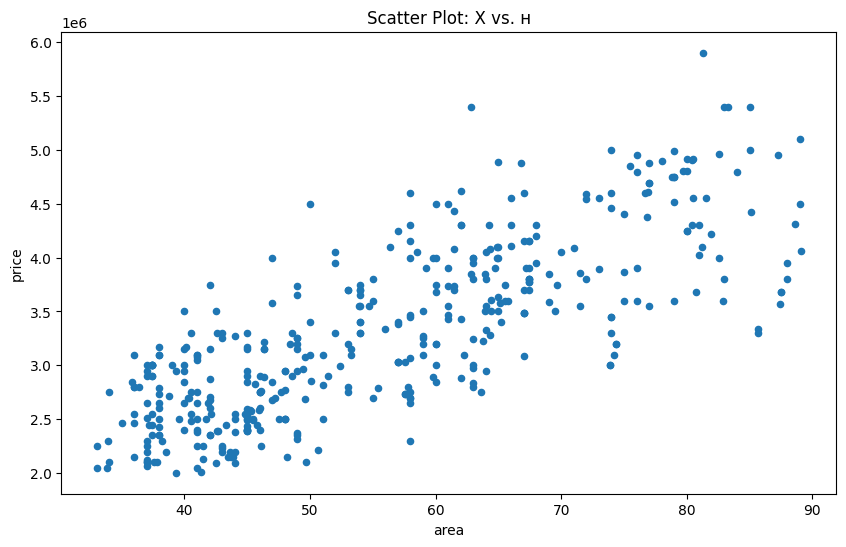

In [ ]:
df48.plot.scatter(
    x="area", y="price",
    colormap="viridis",
    figsize=(10, 6),
    title='Scatter Plot: X vs. н'
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# X = df48[['area', 'rooms']]
X = df48[['area', 'rooms', 'level', 'kitchen_area']]

y = df48['price']

# Делим на train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Используем библиотеку Sklearn для построения модели
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train) # обучение модели
# Выводим параметры модели
print("w0 (intercept):", model.intercept_)
print("w1 (coefficient):", model.coef_)
# Проверяем работу модели на тестовых данных
y_pred = model.predict(X_test) # предсказываем значения для тестовых данных

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

w0 (intercept): 660710.0416105669
w1 (coefficient): [41418.50289739 12305.5296979  10433.59778594 21236.5099384 ]
MSE:  273117353447.9825
RMSE: 522606.3083
MAE:  426632.9099
R^2:  0.5893


Geopandas

In [ ]:
import geopandas as gpd
dfgeo = df.query('id_region == 48')[:20]
print(len(dfgeo))
dfgeo


20


,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
25,2021-01-01,1250000,2,2,3,70.70,11.0,52.859067,39.818296,4,0,399140.0,NaN,48,NaN
144,2021-01-01,2220000,11,18,1,37.01,0.0,52.587696,39.523726,0,0,398004.0,NaN,48,NaN
338,2021-01-01,2500000,3,11,1,44.00,0.0,52.599340,39.568217,0,0,398024.0,NaN,48,NaN
533,2021-01-01,730000,2,5,1,12.00,-100.0,52.537743,39.573170,4,0,398006.0,NaN,48,NaN
796,2021-01-01,2620000,7,14,2,52.00,9.0,59.958034,30.444417,4,0,195248.0,NaN,48,NaN
804,2021-01-01,1350000,3,5,1,30.90,6.1,52.612829,38.474387,4,0,399784.0,NaN,48,NaN
1280,2021-01-01,1580000,1,9,1,36.00,-100.0,52.587129,39.581805,2,0,398008.0,128672.0,48,1985774.0
1410,2021-01-01,2400000,5,5,3,58.00,-100.0,53.019170,39.127773,4,0,399610.0,NaN,48,NaN
1444,2021-01-01,780000,2,2,2,42.50,-100.0,52.606645,38.484927,4,0,399772.0,NaN,48,NaN
1454,2021-01-01,2150000,8,17,1,42.40,11.0,52.631889,39.546580,2,2,398037.0,189890.0,48,2052766.0


In [ ]:
from shapely.geometry import Point

# Создание геометрии
dfgeo['geometry'] = dfgeo.apply(lambda row: Point(row.geo_lon, row.geo_lat), axis=1)

# Преобразование в GeoDataFrame
gdf = gpd.GeoDataFrame(dfgeo, geometry='geometry', crs="EPSG:4326")  # WGS84

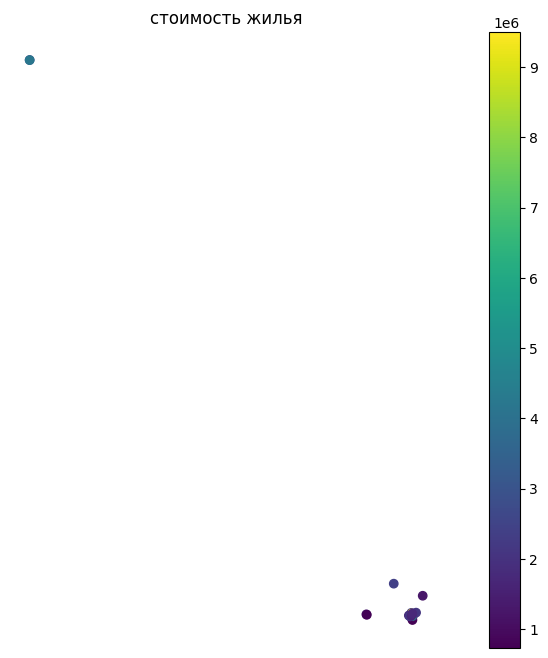

In [ ]:
# Базовая карта
ax = gdf.plot(column='price', cmap='viridis', legend=True, figsize=(12, 8))

# Настройка отображения
ax.set_title('стоимость жилья')
ax.set_axis_off()  # Убрать оси

# Показать карту
plt.show()

In [ ]:
!pip install contextily

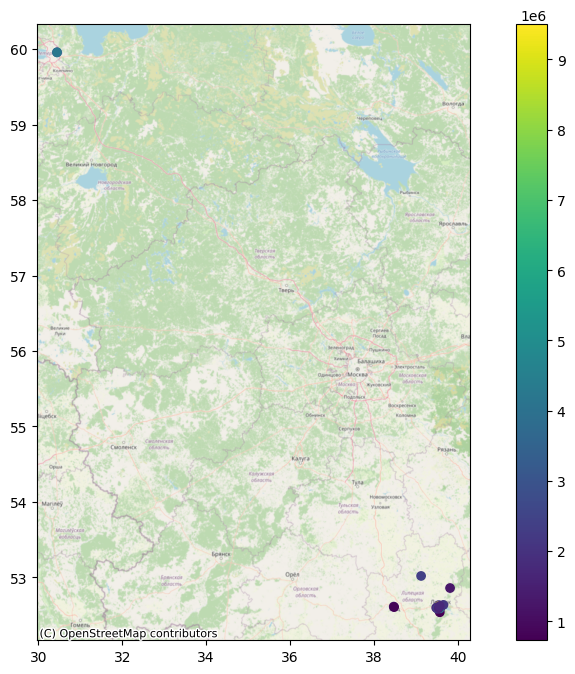

In [ ]:
import contextily as cx

ax = gdf.plot(column='price', cmap='viridis', legend=True, figsize=(12, 8))
cx.add_basemap(ax, crs=gdf.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)
plt.show()

In [ ]:
import geopandas as gpd

# Предположим, gdf уже создан
interactive_map = gdf.explore(marker_type='marker', column='price', cmap='viridis', legend=True, tiles="CartoDB Positron")
# interactive_map.show_in_browser()
outfp = "real_estate_2021_map.html"
interactive_map.save(outfp)

Folium

In [ ]:
import folium
import pandas as pd
import numpy as np
from folium.plugins import MarkerCluster, HeatMap

In [ ]:
# Проверка наличия координат
print(f"Строк с координатами: {df48[['geo_lat', 'geo_lon']].notna().all(axis=1).sum()}")

# Удаление строк без координат
df_clean = df48.dropna(subset=['geo_lat', 'geo_lon']).copy()

# Фильтрация корректных координат для России
df_clean = df_clean[
    (df_clean['geo_lat'] >= 41) & (df_clean['geo_lat'] <= 82) &
    (df_clean['geo_lon'] >= 19) & (df_clean['geo_lon'] <= 179)
]

Строк с координатами: 424


In [ ]:
# Создание карты с центром в Москве
map = folium.Map(
    location=[55.7558, 37.6173],
    zoom_start=6,
    #tiles='CartoDB Positron',
    tiles='OpenStreetMap',
)
# Добавление маркеров (выборка для производительности)
sample_df = df_clean.sample(min(100, len(df_clean)))

for idx, row in sample_df.iterrows():
    popup_text = (
        f"<b>Регион:</b> {row['id_region']}<br>"
        f"<b>Цена:</b> {row['price']:,.0f} руб.<br>"
        f"<b>Площадь:</b> {row['area']:.1f} м²<br>"
        f"<b>Комнат:</b> {row.get('rooms', 'н/д')}<br>"
        f"<b>Этаж:</b> {row.get('level', 'н/д')}"
    )
    folium.Marker(
        location=[row['geo_lat'], row['geo_lon']],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=f"Цена: {row['price']:,.0f} руб.",
        icon=folium.Icon(color='blue', icon='home')
    ).add_to(map)

map.save('real_estate_basic_map.html')

map



In [ ]:
m_cluster = folium.Map(
    location=[55.7558, 37.6173],
    zoom_start=5,
    tiles='OpenStreetMap'
)

marker_cluster = MarkerCluster().add_to(m_cluster)

for idx, row in df_clean.sample(len(df_clean)).iterrows():
    popup_text = f"Цена: {row['price']:,.0f} руб., Площадь: {row['area']:.0f} м²"
    folium.Marker(
        [row['geo_lat'], row['geo_lon']],
        popup=folium.Popup(popup_text, max_width=250),
        icon=None
    ).add_to(marker_cluster)

m_cluster.save('real_estate_cluster_map.html')
m_cluster

In [ ]:
m_heat = folium.Map(
    location=[55.7558, 37.6173],
    zoom_start=5
)

# Подготовка данных для тепловой карты
heat_data = [
    [row['geo_lat'], row['geo_lon'], row['price'] / 1_000_000]  # Цена в млн руб.
    for idx, row in df_clean.iterrows()
]

HeatMap(
    heat_data,
    radius=15,
    blur=10,
    max_zoom=13,
    gradient={0.4: 'blue', 0.6: 'cyan', 0.7: 'lime', 0.8: 'yellow', 1.0: 'red'}
).add_to(m_heat)

m_heat.save('real_estate_heatmap.html')
m_heat